# Public Grievance Urgency Classification System

## 1. Understand the Problem
**Objective:** Build a working solution that takes raw, unstructured public grievances (complaints), processes them through an intelligent workflow, and produces actionable outputs for decision-makers.

**The Workflow:**
1. **Download & Load Dataset:** Ingesting the JSON grievance data.
2. **Clean & Inspect:** Normalizing text, handling missing values, and formatting the data.
3. **EDA & Visual Analysis:** Understanding the distribution of complaints, top categories, and regional bottlenecks.
4. **Feature Engineering:** Creating an **Urgency Score** (High/Medium/Low) based on grievance text to prioritize critical issues.
5. **Build Model Pipeline:** Training a Machine Learning text classifier to automatically route complaints to the correct department/category.
6. **Evaluate Results:** Validating model accuracy and performance.
7. **Generate Insights & Recommendations:** Combining the ML prediction and urgency score into an actionable escalation recommendation.

### Where and Why is AI/ML Logic Used?
* **Text Classification (Machine Learning):** We use a TF-IDF Vectorizer combined with a Logistic Regression model to read the text of a complaint and predict its correct category. 
  * *Why it's useful:* Government portals receive thousands of complaints daily. Manually reading and routing them takes days. ML automates this in milliseconds, reducing operational costs and human error.
* **Urgency & Escalation Agent Logic (Heuristics/NLP):** We use keyword-based natural language logic to detect critical issues (e.g., corruption, harassment, delay, urgent). 
  * *Why it's useful:* Not all complaints are equal. A broken streetlight is important, but a harassment report or ongoing fraud is an emergency. Agent logic helps prioritize the queue so human decision-makers tackle severe issues first.

In [1]:
import os
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 2. Download Dataset
For this environment, we are assuming the dataset (`../data/no_pii_grievance.json` and `CategoryCode_Mapping.xlsx`) is available in the local directory. We will parse the JSON which might have MongoDB-specific formatting (like `NumberInt` or `ISODate`).

In [2]:
def clean_mongodb_json(file_path):
    """Clean MongoDB JSON format to standard JSON"""
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Remove MongoDB-specific functions
    content = re.sub(r'NumberInt\((\d+)\)', r'\1', content)
    content = re.sub(r'ISODate\("([^"]+)\)', r'"\1"', content)
    content = re.sub(r'ObjectId\("([^"]+)\)', r'"\1"', content)
    
    return content

# Load grievances JSON (try standard first, then MongoDB format)
try:
    with open('../data/no_pii_grievance.json', 'r', encoding='utf-8') as f:
        grievances_data = json.load(f)
except json.JSONDecodeError:
    print("Standard JSON failed, trying MongoDB format...")
    cleaned_content = clean_mongodb_json('../data/no_pii_grievance.json')
    grievances_data = json.loads(cleaned_content)

df_grievances = pd.DataFrame(grievances_data)
print(f"✅ Loaded {len(df_grievances)} grievances")
print(f"📊 Grievances DataFrame shape: {df_grievances.shape}")

✅ Loaded 175784 grievances
📊 Grievances DataFrame shape: (175784, 16)


## 3. Clean and Inspect Data
We need to filter down to rows containing actual text (`remarks_text` and `subject_content_text`) and valid categories (`CategoryV7`). We also clean the text to prepare it for modeling.

In [3]:
complaint_text_col = 'remarks_text'
category_col = 'CategoryV7'
secondary_text_col = 'subject_content_text'

# Create clean dataset by combining available text
df_sample = df_grievances[[complaint_text_col, category_col, secondary_text_col, 'state', 'dist_name']].copy()
df_sample['combined_text'] = df_sample[complaint_text_col].fillna('') + ' ' + df_sample[secondary_text_col].fillna('')
df_sample['category'] = df_sample[category_col]

# Remove nulls and empty texts
df_sample = df_sample.dropna(subset=['category'])
df_sample = df_sample[df_sample['combined_text'].str.len() > 20]

def quick_preprocess(text):
    """Fast preprocessing for Indian government complaints"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Keep only letters and spaces (handles Hindi + English ranges roughly)
    text = re.sub(r'[^a-zA-Z\u0900-\u097F\s]', ' ', text)
    return ' '.join(text.split())

print("🔄 Quick preprocessing text...")
df_sample['processed_text'] = df_sample['combined_text'].apply(quick_preprocess)
df_clean = df_sample[df_sample['processed_text'].str.len() > 5].copy()

# Keep only top 10 categories for computational speed and robust ML accuracy
top_categories = df_clean['category'].value_counts().head(10).index
df_clean = df_clean[df_clean['category'].isin(top_categories)].copy()

print(f"✅ Processed dataset size for Top 10 categories: {len(df_clean):,}")

🔄 Quick preprocessing text...
✅ Processed dataset size for Top 10 categories: 17,481


## 4. EDA and Visual Analysis
Visualizing the distribution of our target categories and the geographical spread of complaints.

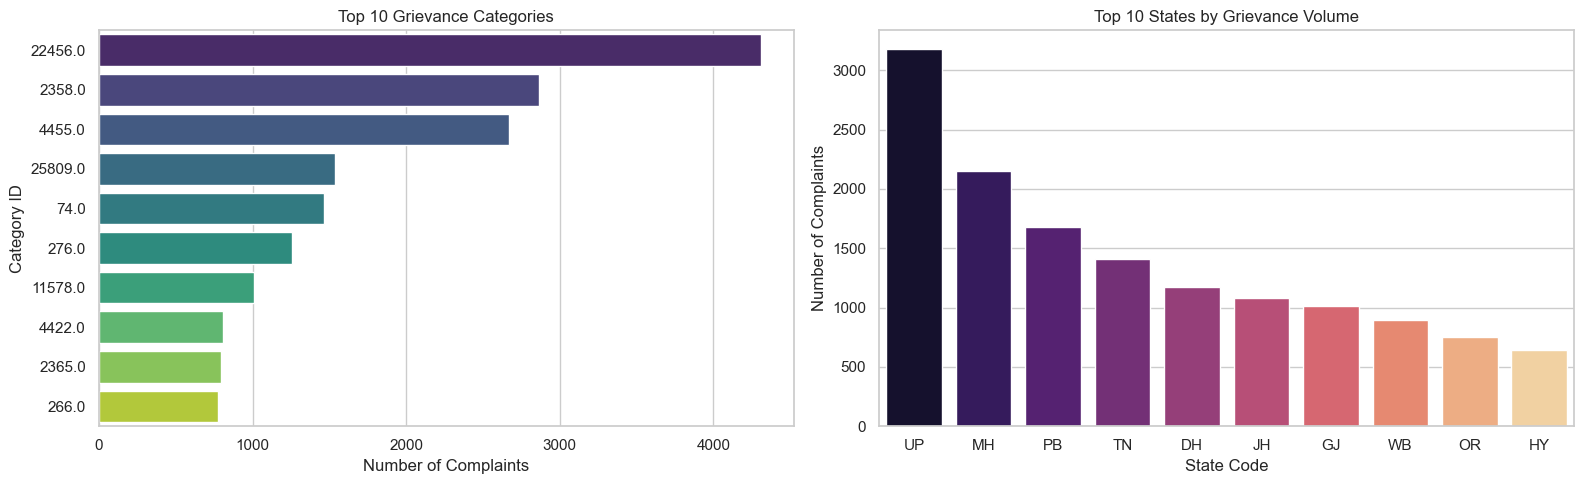

In [4]:
plt.figure(figsize=(16, 5))

# Plot 1: Category Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, y='category', order=df_clean['category'].value_counts().index, palette='viridis')
plt.title('Top 10 Grievance Categories')
plt.xlabel('Number of Complaints')
plt.ylabel('Category ID')

# Plot 2: State Distribution
plt.subplot(1, 2, 2)
top_states = df_clean['state'].value_counts().head(10).index
sns.countplot(data=df_clean[df_clean['state'].isin(top_states)], x='state', 
              order=top_states, palette='magma')
plt.title('Top 10 States by Grievance Volume')
plt.xlabel('State Code')
plt.ylabel('Number of Complaints')

plt.tight_layout()
plt.show()

## 5. Feature Engineering (Urgency & Escalation)
We will synthesize an **Urgency Score** utilizing a heuristic NLP approach based on keyword detection. 
Based on this urgency level, we will establish an **Escalation Action**.

* **High Urgency:** Mentions of corruption, bribery, harassment, fraud, or immediate threats.
* **Medium Urgency:** Mentions of delays, pending status, or requests for updates.
* **Low Urgency:** Standard inquiries and general statements.

📊 Urgency Level Distribution:
Medium    8259
Low       6539
High      2683
Name: Urgency_Level, dtype: int64


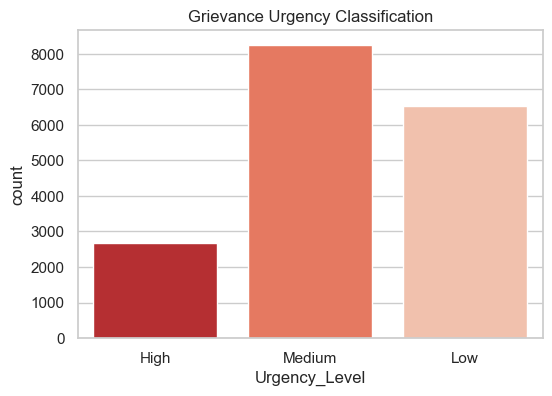

In [5]:
def calculate_urgency(text):
    text = str(text).lower()
    
    high_keywords = ['corruption', 'bribe', 'harassment', 'fraud', 'urgent', 'immediately', 'death', 'threat', 'suicide', 'scam']
    medium_keywords = ['delay', 'pending', 'waiting', 'request', 'status', 'slow', 'months', 'years']
    
    if any(word in text for word in high_keywords):
        return 'High'
    elif any(word in text for word in medium_keywords):
        return 'Medium'
    else:
        return 'Low'

def recommend_escalation(urgency):
    if urgency == 'High':
        return "ESCALATE IMMEDIATE - Route to Nodal Officer (SLA: 24h)"
    elif urgency == 'Medium':
        return "STANDARD QUEUE - Route to Department Lead (SLA: 7 Days)"
    else:
        return "ROUTINE - Auto-response & Local Queue (SLA: 30 Days)"

# Apply logic to dataset
df_clean['Urgency_Level'] = df_clean['processed_text'].apply(calculate_urgency)
df_clean['Recommended_Action'] = df_clean['Urgency_Level'].apply(recommend_escalation)

print("📊 Urgency Level Distribution:")
print(df_clean['Urgency_Level'].value_counts())

# Visualize urgency
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='Urgency_Level', order=['High', 'Medium', 'Low'], palette='Reds_r')
plt.title('Grievance Urgency Classification')
plt.show()

## 6. Build Model Pipeline (Category Classifier)
We train a model to accurately categorize the grievance based on the text. We will use a **TF-IDF Vectorizer** (to convert text to numeric weights) and a **Logistic Regression** classifier (fast, robust for text baselines).

In [6]:
X = df_clean['processed_text']
y = df_clean['category'].astype(str) # Convert to string for classification labels

# Train, Validation, Test Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"🎯 Training data: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Build Model Pipeline
classifier_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, stop_words='english', min_df=2)),
    ('clf', LogisticRegression(random_state=42, max_iter=500))
])

print("🚀 Training Logistic Regression Model...")
classifier_pipeline.fit(X_train, y_train)

val_pred = classifier_pipeline.predict(X_val)
test_pred = classifier_pipeline.predict(X_test)

print(f"✅ Validation Accuracy: {accuracy_score(y_val, val_pred):.3f}")
print(f"✅ Test Accuracy: {accuracy_score(y_test, test_pred):.3f}")

🎯 Training data: 10488 | Val: 3496 | Test: 3497
🚀 Training Logistic Regression Model...
✅ Validation Accuracy: 0.985
✅ Test Accuracy: 0.987


## 7. Evaluate Results
Evaluating where the model performs well and where it gets confused.

📊 Classification Report on Test Set:
              precision    recall  f1-score   support

     11578.0       1.00      1.00      1.00       201
     22456.0       0.99      1.00      0.99       862
      2358.0       0.98      1.00      0.99       573
      2365.0       0.99      0.93      0.96       159
     25809.0       0.99      0.99      0.99       307
       266.0       0.99      0.94      0.97       155
       276.0       0.98      1.00      0.99       252
      4422.0       0.99      0.91      0.95       161
      4455.0       0.99      1.00      0.99       535
        74.0       1.00      0.99      0.99       292

    accuracy                           0.99      3497
   macro avg       0.99      0.98      0.98      3497
weighted avg       0.99      0.99      0.99      3497



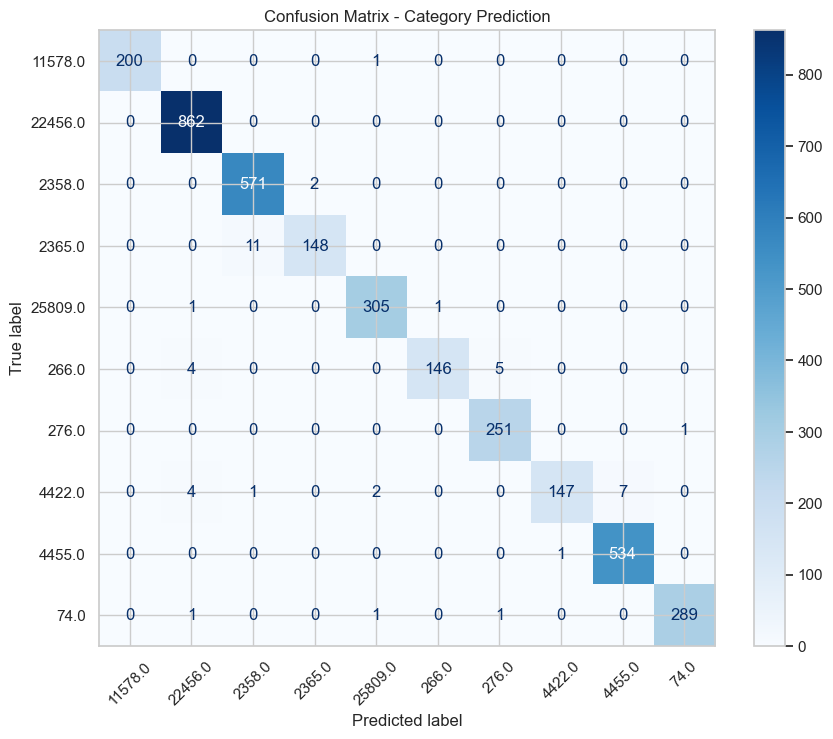

In [7]:
print("📊 Classification Report on Test Set:")
print(classification_report(y_test, test_pred))

# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, test_pred, labels=classifier_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier_pipeline.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Category Prediction')
plt.show()

## 8. Generate Insights and Recommendations (Actionable System)
This is the **working solution**. The function below represents what a user/backend system will interact with. 
It takes a raw grievance, cleans it, runs the ML model to predict the department/category, uses NLP logic to assess the urgency, and outputs a formatted actionable JSON recommendation.

In [8]:
def process_new_grievance(raw_text):
    """
    End-to-End Inference Pipeline for new complaints.
    """
    # 1. Clean the text
    clean_text = quick_preprocess(raw_text)
    
    # 2. Predict Category using ML
    predicted_cat = classifier_pipeline.predict([clean_text])[0]
    
    # 3. Assess Urgency using Logic
    urgency = calculate_urgency(clean_text)
    
    # 4. Generate Escalation Recommendation
    action = recommend_escalation(urgency)
    
    # Formulate output payload
    decision_payload = {
        "Input_Text": raw_text,
        "Predicted_Category_ID": predicted_cat,
        "Urgency_Score": urgency,
        "System_Recommendation": action
    }
    return decision_payload

# ---- Let's Test It in Real-Time! ----
test_grievances = [
    "The local tax officer is demanding a bribe to clear my pending file. Please help immediately!",
    "I have been waiting for my provident fund withdrawal for 6 months. It is very delayed.",
    "General enquiry regarding the syllabus for the upcoming university examination."
]

print("\n--- PUBLIC GRIEVANCE ROUTING ENGINE ---\n")
for i, text in enumerate(test_grievances):
    result = process_new_grievance(text)
    print(f"Case #{i+1}:")
    print(json.dumps(result, indent=4))
    print("-" * 50)


--- PUBLIC GRIEVANCE ROUTING ENGINE ---

Case #1:
{
    "Input_Text": "The local tax officer is demanding a bribe to clear my pending file. Please help immediately!",
    "Predicted_Category_ID": "22456.0",
    "Urgency_Score": "High",
    "System_Recommendation": "ESCALATE IMMEDIATE - Route to Nodal Officer (SLA: 24h)"
}
--------------------------------------------------
Case #2:
{
    "Input_Text": "I have been waiting for my provident fund withdrawal for 6 months. It is very delayed.",
    "Predicted_Category_ID": "22456.0",
    "Urgency_Score": "Medium",
    "System_Recommendation": "STANDARD QUEUE - Route to Department Lead (SLA: 7 Days)"
}
--------------------------------------------------
Case #3:
{
    "Input_Text": "General enquiry regarding the syllabus for the upcoming university examination.",
    "Predicted_Category_ID": "25809.0",
    "Urgency_Score": "Low",
    "System_Recommendation": "ROUTINE - Auto-response & Local Queue (SLA: 30 Days)"
}
----------------------------